# Manual annotation - subset clusters

In [ ]:
# eval "$(conda shell.bash hook)"
# conda init
# conda activate /work/islet_cartography_scrna/scrna_cartography_py_analysis
# python -m ipykernel install --user --name scrna_cartography_py_analysis --display-name "py_analysis"

In [1]:
# Path and system utilities
import os                    # Operating system interface
import sys                   # System-specific parameters and functions
import glob                  # File pattern matching
from pathlib import Path     # Object-oriented filesystem paths
from pyhere import here      # Reproducible project paths

# Single-cell data handling
import anndata as ad            # Core data structure for single-cell data
import scanpy as sc          # Analysis and visualization of single-cell data
import pyucell as uc         # Module score

# dataframes
import pandas as pd
import numpy as np
# Micellaneous utilities
import warnings              # Suppress or manage warnings

# Custom modules and functions
sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import my_anndata as ma                    # Custom AnnData utilities
import misc as mi
import diff_genes as dg

In [2]:
# Paths
base_dir = str(here('data/annotate/'))
plot_dir = os.path.join(base_dir, 'plot') 
files_dir = os.path.join(base_dir, 'files') 

anndata_dir = str(here('data/anndata/'))
harmo_dir = Path(here('data/marker_database/harmonized'))

In [6]:
# Adata object
adata = ad.read_h5ad(os.path.join(anndata_dir, "AG_combined.h5ad"))

In [95]:
# parameters
cluster_key = 'leiden_1.5'

categories: 0, 1, 2, etc.
var_group_labels: stellate_cells, quiescent_cells, activated_stellate_cells, etc.


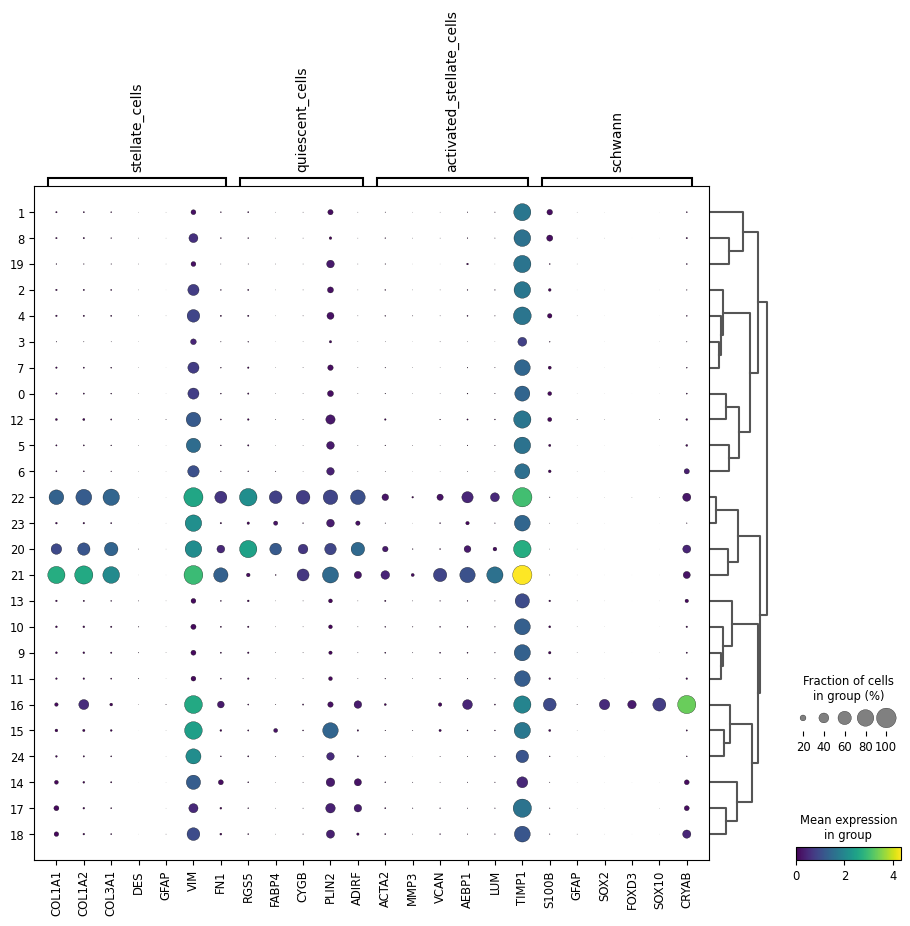

In [240]:
cell_gene_dict = {
    "stellate_cells": ["COL1A1", "COL1A2", "COL3A1", "DES", "GFAP", "VIM", "FN1"],
    "quiescent_cells": ["RGS5", "FABP4", "CYGB", "PLIN2", "ADIRF"],
    "activated_stellate_cells": ["ACTA2", "MMP3", "VCAN", "AEBP1", "LUM", "TIMP1"],
    "schwann": ["S100B", "GFAP", "SOX2", "FOXD3", "SOX10", "CRYAB"]
}

sc.pl.dotplot(adata, cell_gene_dict, groupby = 'leiden_1.5', dendrogram= True, cmap="viridis", save = True)

## Subcluster cluster 22

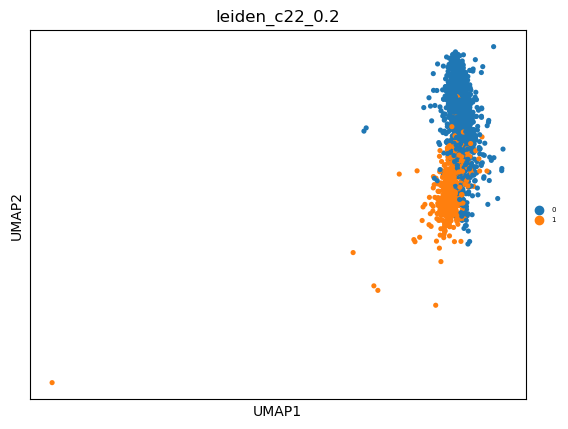

In [12]:
adata_22 = adata[adata.obs[cluster_key] == "22"].copy()
sc.tl.leiden(adata_22, n_iterations=-1, flavor = 'igraph', key_added = 'leiden_c22_0.2', random_state= 1000, resolution = 0.2)
sc.pl.umap(adata_22, color = "leiden_c22_0.2", legend_fontsize= 5)

### Combine with original data

In [16]:
# create an empty column in the full object
adata.obs['leiden_1.5_subcluster'] = adata.obs['leiden_1.5'].astype(str)
adata.obs.loc[adata_22.obs_names, 'leiden_1.5_subcluster'] = (
    '22_' + adata_22.obs['leiden_c22_0.2'].astype(str)
)

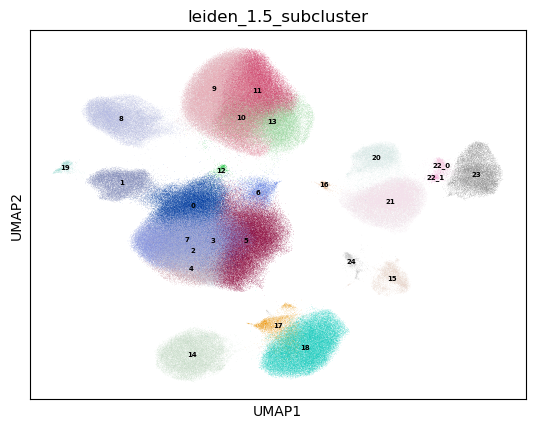

In [18]:
sc.pl.umap(adata, color = "leiden_1.5_subcluster", legend_loc='on data', legend_fontsize= 5)

In [21]:
## Differential expressed genes
# 22_0 vs 22_1 and 22_0 vs 23, and 22_1 vs 23
cluster_key = 'leiden_1.5_subcluster'
sample_key = 'ic_id_platform_adjusted_sample'
design= '~ ic_id_platform_adjusted_sample + leiden_1.5_subcluster'
# subset
adata_sub = adata[adata.obs[cluster_key].isin(["22_0", "22_1", "23"])].copy()
# prc of expressed genes
pct_genes_df = dg.compute_pct_expressing(ad = adata, cluster_key = cluster_key, layer="counts", workers=60)
dds = dg.prepare_pseudobulk_deseq_analysis(ad = adata_sub, 
                                           n_cells = 25,
                                           sample_key = sample_key, 
                                           cluster_key = cluster_key, 
                                           design = design, 
                                           layer='counts', 
                                           func='sum', 
                                           workers=60)
comparisons = [("22_0", "23"),
               ("22_1", "23"),
               ("22_0", "22_1"),
               ("22_1", "22_0")]

# Wald test
results_list = [
    dg.diff_genes_two_clusters(dds_obj = dds, cluster_index=cluster_key,
                            cluster_1=c1, cluster_2=c2, workers=60).assign(comparison=f"{c1}_vs_{c2}")
    for c1, c2 in comparisons
]

all_results = dg.extract_results(comparisons = comparisons, results_list = results_list, pct_genes_df=pct_genes_df)

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.22 seconds.

Fitting dispersions...
... done in 3.22 seconds.

Fitting dispersion trend curve...
... done in 0.53 seconds.

Fitting MAP dispersions...
... done in 5.79 seconds.

Fitting LFCs...
... done in 9.79 seconds.

Calculating cook's distance...
... done in 0.26 seconds.

Replacing 0 outlier genes.



### Save results

In [23]:
all_results.to_csv(os.path.join(files_dir, "deg_wald_22_subcluster_vs_23.csv"), index_label= "gene_symbol")

### Expression of marker genes

In [182]:
all_results = pd.read_csv(os.path.join(files_dir, "deg_wald_22_subcluster_vs_23.csv"), index_col = 0)
# only keep comparison to cluster 23
# results_flt = all_results.query(
#     'padj <= 0.01 and abs(log2FoldChange) >= 1 and comparison not in ["22_0_vs_22_1", "22_1_vs_22_0"]')

results_flt = all_results.copy()

In [193]:
# Define your endothelial markers
endo_markers = {
    "endothelial": ["PLVAP", "CLDN5", "PECAM1", "VWF", "CDH5", "KDR", "FLT1"], 
    "islet_endothelial_cells": ["ACE", "PASK", "F2RL3", "ESM1", "CXCR4", "UNC5B", "LAMA4", "CREM", "COL13A1", "NKX2-3", "ANGPTL2", "THBS1"],
    "endmt": ["S100A4", "APOE", "TGFBI", "C3AR1", "LGALS3", "COL1A1", "CDH2"]
}

# Step 1: Filter by significance and fold change, excluding specific comparisons
results_flt = all_results.query(
    'comparison not in ["22_0_vs_22_1", "22_1_vs_22_0"]'
)

# Step 2: Flatten all marker genes into a single list
genes_of_interest = [gene for gene_list in endo_markers.values() for gene in gene_list]

# Step 3: Filter for marker genes
filtered_results = results_flt[results_flt.index.isin(genes_of_interest)].copy()

# Step 4: Add a category column for each gene
gene_to_category = {gene: category for category, genes in endo_markers.items() for gene in genes}
filtered_results['category'] = filtered_results.index.map(gene_to_category)

categories: 22_0, 22_1, 23
var_group_labels: endothelial, islet_endothelial_cells, endmt


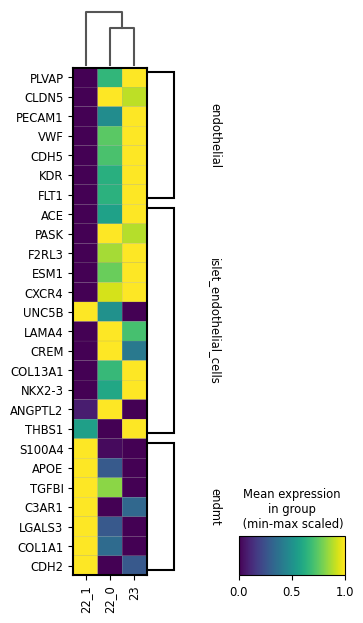

In [222]:
sc.pl.matrixplot(adata_sub, endo_markers, groupby="leiden_1.5_subcluster", cmap="viridis",  standard_scale='var', dendrogram=True, swap_axes= True, figsize=(3.5,7),
                colorbar_title = 'Mean expression\nin group\n (min-max scaled)')

categories: 22_0, 22_1, 23
var_group_labels: endothelial, islet_endothelial_cells, endmt


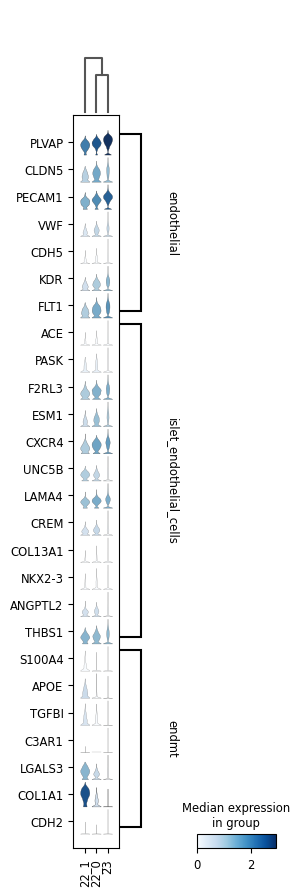

In [199]:
endo_markers = {
    "endothelial": ["PLVAP", "CLDN5", "PECAM1", "VWF", "CDH5", "KDR", "FLT1"], 
    "islet_endothelial_cells": ["ACE", "PASK", "F2RL3", "ESM1", "CXCR4", "UNC5B", "LAMA4", "CREM", "COL13A1", "NKX2-3", "ANGPTL2", "THBS1"], #https://www.nature.com/articles/s41467-024-55415-3
    "endmt": ["S100A4", "APOE", "TGFBI", "C3AR1", "LGALS3", "COL1A1", "CDH2"]
}

# COL1A1 https://www.nature.com/articles/s41419-021-03920-4
sc.tl.dendrogram(adata_sub, groupby="leiden_1.5_subcluster", use_rep='X_latent_1')
sc.pl.stacked_violin(adata_sub, 
              var_names =endo_markers,
             groupby = "leiden_1.5_subcluster", swap_axes=True, dendrogram=True)

## EC to mesenchymal or myofibroblast?

https://www.nature.com/articles/s41419-021-03603-0#ref-CR7
https://publications.ersnet.org/content/erj/61/6/2201799

## Acinar cells
https://www.gastrojournal.org/article/S0016-5085(20)35399-3/fulltext

#### List of marker genes from fig 4A

In [138]:
acinar_genes = {
    "Acinar_i": [
        "RBPJL", "CHRM3", "LRIG1", "INSR",
        "FOXP2", "CHN2", "DTNA", "SDK1",
        "MAP3K5", "CAMK1D"
    ],

    "Acinar_REG+": [
        "REG3A", "REG3G", "REG1B", "REG1A", "CPB1", "CPA1", "PRSS3", "PRSS1",
        "AMY2A", "CELA2A", "CELA3A", "CELA3B",
        "CELA3A", "CELA3B", "CTRB1", "CTRB2",
        "CLPS", "PNLIP", "SPINK1", "CTRC",
        "CPA2", "ANXA4"],

    "Acinar_s": [
        "CPB1", "CPA1", "PRSS3", "PRSS1",
        "AMY2A", "CELA2A", "CELA3A", "CELA3B",
        "CELA3A", "CELA3B", "CTRB1", "CTRB2",
        "CLPS", "PNLIP", "SPINK1", "CTRC",
        "CPA2", "ANXA4"
    ]
}

In [140]:
acinar_genes_reduced = {
    "Acinar_i": [
        "RBPJL", "CHRM3", "LRIG1", "INSR",
        "FOXP2", "CHN2", "DTNA", "SDK1",
        "MAP3K5", "CAMK1D"
    ],

    "Acinar_REG+": [
        "REG3A", "REG3G", "REG1B", "REG1A"],

    "Acinar_s": [
        "CPB1", "CPA1", "PRSS3", "PRSS1",
        "AMY2A", "CELA2A", "CELA3A", "CELA3B",
        "CELA3A", "CELA3B", "CTRB1", "CTRB2",
        "CLPS", "PNLIP", "SPINK1", "CTRC",
        "CPA2", "ANXA4"
    ]
}

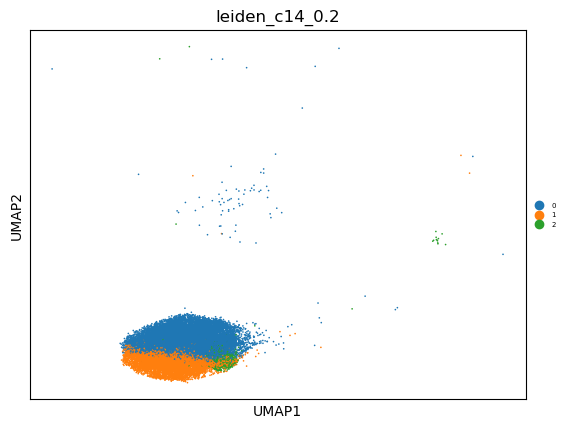

In [154]:
adata_14 = adata[adata.obs[cluster_key] == "14"].copy()
sc.tl.leiden(adata_14, n_iterations=-1, flavor = 'igraph', key_added = 'leiden_c14_0.2', random_state= 1000, resolution = 0.2)
sc.pl.umap(adata_14, color = 'leiden_c14_0.2', legend_fontsize= 5)

#### Ucell score

In [150]:
uc.compute_ucell_scores(adata_14, signatures=acinar_genes, n_jobs= 60)

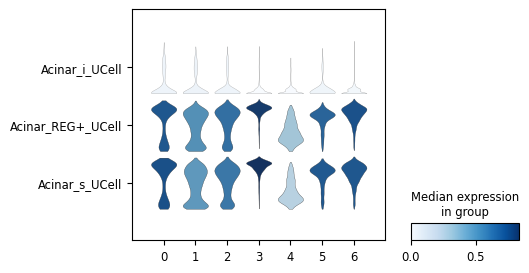

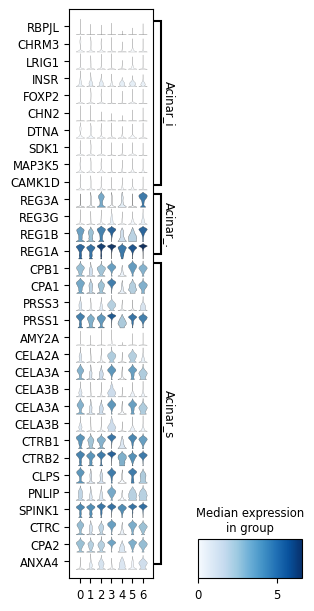

In [151]:
sc.pl.stacked_violin(adata_14, 
              var_names =['Acinar_i_UCell', 'Acinar_REG+_UCell', 'Acinar_s_UCell'],
             groupby = "leiden_c14_0.2", swap_axes=True, figsize=(5,3))
sc.pl.stacked_violin(adata_14, 
              var_names =acinar_genes_reduced,
             groupby = "leiden_c14_0.2", swap_axes=True, figsize=(3,7))

In [88]:
adata_14.obs.pivot_table(
    index='ic_id_study',
    columns='leiden_c14_0.2',
    aggfunc='size',
    fill_value=0
)

leiden_c14_0.2,0,1,2
ic_id_study,,,
ic_1,8,10,0
ic_2,192,63,6
ic_3,116,55,6
ic_4,2,0,0
ic_5,42,56,0
ic_6,57,70,1
ic_7,49,70,6
ic_12,330,352,3
ic_13,23,6,1


### Differential expressed genes

In [70]:
## Differential expressed genes
cluster_key = 'leiden_c14_0.2'
sample_key = 'ic_id_platform_adjusted_sample'
design= '~ ic_id_platform_adjusted_sample + leiden_c14_0.2'

# prc of expressed genes
pct_genes_df = dg.compute_pct_expressing(ad = adata_14, cluster_key = cluster_key, layer="counts", workers=60)
dds = dg.prepare_pseudobulk_deseq_analysis(ad = adata_14, 
                                           n_cells = 25,
                                           sample_key = sample_key, 
                                           cluster_key = cluster_key, 
                                           design = design, 
                                           layer='counts', 
                                           func='sum', 
                                           workers=60)
comparisons = [("0", "1"),
               ("1", "0"),
               ("1", "2"),
               ("2", "1"),
               ("2", "0"),
               ("0", "2")]

# Wald test
results_list = [
    dg.diff_genes_two_clusters(dds_obj = dds, cluster_index=cluster_key,
                            cluster_1=c1, cluster_2=c2, workers=60).assign(comparison=f"{c1}_vs_{c2}")
    for c1, c2 in comparisons
]

all_results = dg.extract_results(comparisons = comparisons, results_list = results_list, pct_genes_df=pct_genes_df)

all_results.to_csv(os.path.join(files_dir, "deg_wald_14_subcluster_vs_eachother.csv"), index_label= "gene_symbol")

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.30 seconds.

Fitting dispersions...
... done in 6.74 seconds.

Fitting dispersion trend curve...
/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.60 seconds.

Fitting MAP dispersions...
... done in 9.41 seconds.

Fitting LFCs...
... done in 17.01 seconds.

Calculating cook's distance...
... done in 0.52 seconds.

Replacing 0 outlier genes.

